# Notebook 04 - Label Distribution & Split Audit

Notebook ini adalah gerbang QA terakhir sebelum masuk ke modeling.

Tujuan:

1. Mengecek distribusi label `None`, `Negatif`, `Netral`, dan `Positif` untuk setiap aspek.
2. Mengecek apakah split `train`, `val`, dan `test` dari Notebook 03 cukup stabil.
3. Menandai label langka atau split yang terlalu sedikit sampelnya.
4. Menentukan rekomendasi evaluasi, terutama `macro-F1`, `weighted-F1`, dan per-aspect F1.
5. Menyimpan ringkasan split final agar semua eksperimen berikutnya memakai pembagian data yang sama.

Notebook ini belum melakukan training model. Modeling dimulai dari Notebook 05.

## Dasar Metodologi

Notebook ini memakai dasar metodologi tambahan di luar paper MABSA utama:

1. **Multi-label / multi-target stratification.** Review hotel MABSA memiliki banyak target sekaligus: 7 aspek dan 4 kelas sentimen. Literatur stratifikasi multi-label menekankan bahwa pembagian train/test perlu mempertahankan distribusi label agar evaluasi tidak bias.

2. **Class imbalance.** Label MABSA biasanya tidak seimbang, terutama kelas `None` yang dominan dan beberapa kelas minoritas seperti `Negatif` atau `Netral` pada aspek tertentu. Karena itu, accuracy saja tidak cukup.

3. **Metric selection.** Untuk data multi-class dan imbalanced, evaluasi perlu memakai macro average, weighted average, dan analisis per kelas/per aspek.

Referensi metodologis:

- Sechidis, Tsoumakas, & Vlahavas (2011), *On the Stratification of Multi-label Data*.
- Szymański & Kajdanowicz (2017), *A Network Perspective on Stratification of Multi-Label Data*. https://proceedings.mlr.press/v74/szyma%C5%84ski17a.html
- Sokolova & Lapalme (2009), *A systematic analysis of performance measures for classification tasks*. https://doi.org/10.1016/j.ipm.2009.03.002
- Buda, Maki, & Mazurowski (2018), *A systematic study of the class imbalance problem in convolutional neural networks*. https://doi.org/10.1016/j.neunet.2018.07.011

### 1. Import Library dan Persiapan Direktori Output


In [1]:
from pathlib import Path
import json
import math
import os
import re
import shutil
from itertools import product

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 160)

SEED = 42
ASPECTS = ["Kamar", "Kebersihan", "Pelayanan", "Harga", "Lokasi", "Fasilitas", "Makanan"]
LABEL_ORDER = ["None", "Negatif", "Netral", "Positif"]
SPLIT_ORDER = ["train", "val", "test"]
DATASET_VARIANTS = {
    "all_valid": "final_review_dataset_all_valid.csv",
    "primary_training": "final_review_dataset_primary_training.csv",
    "core_clean": "final_review_dataset_core_clean.csv",
    "relation_aware": "final_review_dataset_relation_aware.csv",
    "contradiction_ablation": "final_review_dataset_contradiction_ablation.csv",
}

RARE_MIN_COUNT = 10
CRITICAL_MIN_COUNT = 5
MAX_SPLIT_DRIFT_PERCENT = 7.5

IS_KAGGLE = Path("/kaggle").exists()
OUTPUT_DIR = Path("/kaggle/working/mabsa_label_distribution_split_audit_outputs") if IS_KAGGLE else Path("mabsa_label_distribution_split_audit_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR)
print("Kaggle environment:", IS_KAGGLE)

Output directory: /kaggle/working/mabsa_label_distribution_split_audit_outputs
Kaggle environment: True


### 2. Fungsi Pencarian File Input Dataset Final


In [2]:
def find_file(filename):
    candidates = []

    if IS_KAGGLE:
        candidates.append(Path("/kaggle/working/mabsa_final_dataset_outputs") / filename)
        input_root = Path("/kaggle/input")
        if input_root.exists():
            candidates.extend(input_root.rglob(filename))

    local_candidates = [
        Path(r"C:\Users\cencen04_\Documents\Codex\2026-05-23\files-mentioned-by-the-user-data\mabsa_final_dataset_outputs") / filename,
        Path(r"G:\Skripsi\Data Preprocessing\mabsa_final_dataset_outputs") / filename,
    ]
    candidates.extend(local_candidates)

    for path in candidates:
        if path.exists():
            return path

    raise FileNotFoundError(
        f"Tidak menemukan {filename}. Jalankan Notebook 03 lebih dulu atau upload output Notebook 03 sebagai Kaggle input."
    )


paths = {name: find_file(filename) for name, filename in DATASET_VARIANTS.items()}
paths["aspect_long_all_valid"] = find_file("final_aspect_long_all_valid.csv")
paths["image_manifest_all_valid"] = find_file("final_image_manifest_all_valid.csv")
paths["dataset_split_summary"] = find_file("dataset_split_summary.csv")
paths["label_mapping"] = find_file("label_mapping.json")

for name, path in paths.items():
    print(f"{name:28s}: {path}")

all_valid                   : /kaggle/input/notebooks/vince0014/03-final-dataset-builder-and-splits/mabsa_final_dataset_outputs/final_review_dataset_all_valid.csv
primary_training            : /kaggle/input/notebooks/vince0014/03-final-dataset-builder-and-splits/mabsa_final_dataset_outputs/final_review_dataset_primary_training.csv
core_clean                  : /kaggle/input/notebooks/vince0014/03-final-dataset-builder-and-splits/mabsa_final_dataset_outputs/final_review_dataset_core_clean.csv
relation_aware              : /kaggle/input/notebooks/vince0014/03-final-dataset-builder-and-splits/mabsa_final_dataset_outputs/final_review_dataset_relation_aware.csv
contradiction_ablation      : /kaggle/input/notebooks/vince0014/03-final-dataset-builder-and-splits/mabsa_final_dataset_outputs/final_review_dataset_contradiction_ablation.csv
aspect_long_all_valid       : /kaggle/input/notebooks/vince0014/03-final-dataset-builder-and-splits/mabsa_final_dataset_outputs/final_aspect_long_all_valid.csv

### 3. Memuat Dataset Varian dan File Konfigurasi Lintas Dataset


In [3]:
datasets = {name: pd.read_csv(path) for name, path in paths.items() if name in DATASET_VARIANTS}
aspect_long = pd.read_csv(paths["aspect_long_all_valid"])
image_manifest = pd.read_csv(paths["image_manifest_all_valid"])
dataset_split_summary = pd.read_csv(paths["dataset_split_summary"])

with open(paths["label_mapping"], "r", encoding="utf-8") as f:
    label_mapping = json.load(f)

for name, df in datasets.items():
    print(f"{name:24s}: {df.shape}")

print("aspect_long:", aspect_long.shape)
print("image_manifest:", image_manifest.shape)
print("label_mapping:", label_mapping)

display(datasets["primary_training"].head(3))

all_valid               : (8030, 66)
primary_training        : (6854, 66)
core_clean              : (4628, 66)
relation_aware          : (6837, 66)
contradiction_ablation  : (1176, 66)
aspect_long: (56210, 32)
image_manifest: (17371, 35)
label_mapping: {'label_to_id': {'None': 0, 'Negatif': 1, 'Netral': 2, 'Positif': 3}, 'id_to_label': {'0': 'None', '1': 'Negatif', '2': 'Netral', '3': 'Positif'}, 'aspect_to_id': {'Kamar': 0, 'Kebersihan': 1, 'Pelayanan': 2, 'Harga': 3, 'Lokasi': 4, 'Fasilitas': 5, 'Makanan': 6}}


,ID_Review,Platform,Wilayah,Nama_Hotel,Review_Date,Text_Review,image_count,image_files_sample,dataset_role,split,split_strata,relation_category,relation_strength,policy_bucket,recommended_fusion_strategy,is_excluded_final,primary_training_candidate,core_clean_candidate,relation_aware_candidate,contradiction_ablation_candidate,text_aspects,image_aspects,shared_aspects,hard_contradiction_aspects,soft_disagreement_aspects,text_aspect_count,image_aspect_count,shared_aspect_count,hard_contradiction_count,soft_disagreement_count,relation_overlap_ratio,label_text_Kamar,label_text_id_Kamar,label_image_agg_Kamar,label_image_mode_Kamar,label_image_mode_id_Kamar,label_text_Kebersihan,label_text_id_Kebersihan,label_image_agg_Kebersihan,label_image_mode_Kebersihan,label_image_mode_id_Kebersihan,label_text_Pelayanan,label_text_id_Pelayanan,label_image_agg_Pelayanan,label_image_mode_Pelayanan,label_image_mode_id_Pelayanan,label_text_Harga,label_text_id_Harga,label_image_agg_Harga,label_image_mode_Harga,label_image_mode_id_Harga,label_text_Lokasi,label_text_id_Lokasi,label_image_agg_Lokasi,label_image_mode_Lokasi,label_image_mode_id_Lokasi,label_text_Fasilitas,label_text_id_Fasilitas,label_image_agg_Fasilitas,label_image_mode_Fasilitas,label_image_mode_id_Fasilitas,label_text_Makanan,label_text_id_Makanan,label_image_agg_Makanan,label_image_mode_Makanan,label_image_mode_id_Makanan
0,10,Traveloka,Bandung,Atlantic City Hotel,1/17/2026,"Diizinkan check-in sebelum jam 12 siang mungkin karena kami dari luar kota, semua staf ramah dan mendapat hadiah voucher makan malam Natal, terima kasih.",2,R10_G1_8debfff9.jpg|R10_G2_b29ac5d6.jpg,relation_aware_training,test,relation_aware_training__uncorrelated_different_aspects,uncorrelated_different_aspects,low,relation_aware_training,relevance_aware_gated_fusion,False,True,False,True,False,Pelayanan,Kebersihan|Lokasi|Makanan,NaN,NaN,NaN,1,3,0,0,0,0.0000,NaN,0,NaN,NaN,0,NaN,0,Positif,Positif,3,Positif,3,NaN,NaN,0,NaN,0,NaN,NaN,0,NaN,0,Positif,Positif,3,NaN,0,NaN,NaN,0,NaN,0,Positif,Positif,3
1,100,Traveloka,Bandung,Atlantic City Hotel,9/24/2022,"Lokasi strategis. Petugas ramah. Sekuriti top abis, ramah dan pintar memarkirkan mobil, walaupun sempit parkiran di basement, jadi mudah. Makanan rating 7/1...",9,R100_G1_3131b00a.jpg|R100_G2_a4e9a23b.jpg|R100_G3_4541d369.jpg|R100_G4_70815ec9.jpg|R100_G5_898c941e.jpg|R100_G6_57cc0cdf.jpg|R100_G7_5a2d3bd7.jpg|R100_G8_e...,core_clean_training,train,core_clean_training__correlated_non_contradictive,correlated_non_contradictive,high,core_clean_training,standard_text_image_fusion,False,True,True,True,False,Harga|Kamar|Kebersihan|Lokasi|Makanan|Pelayanan,Fasilitas|Kamar|Kebersihan|Lokasi|Pelayanan,Kamar|Kebersihan|Lokasi|Pelayanan,NaN,Kamar,6,5,4,0,1,0.5714,Netral,2,Positif,Positif,3,Positif,3,Netral|Positif,Mixed,-1,Positif,3,Positif,Positif,3,Positif,3,NaN,NaN,0,Positif,3,Netral|Positif,Mixed,-1,NaN,0,Positif,Positif,3,Netral,2,NaN,NaN,0
2,1001,Traveloka,Bandung,YELLO Hotel Paskal Bandung,3/30/2019,Semuanya baik-baik saja! Satu-satunya hal yang tidak memuaskan hanya tentang spa. Saya ingin mencobanya. Jadi saya menelepon nomor itu dan meminta perawatan...,2,R1001_G1_bdedd868.jpg|R1001_G2_ae650528.jpg,core_clean_training,train,core_clean_training__correlated_non_contradictive,correlated_non_contradictive,medium,core_clean_training,standard_text_image_fusion,False,True,True,True,False,Lokasi|Makanan|Pelayanan,Fasilitas|Harga|Kebersihan|Lokasi,Lokasi,NaN,NaN,3,4,1,0,0,0.1667,NaN,0,NaN,NaN,0,NaN,0,Positif,Positif,3,Positif,3,NaN,NaN,0,NaN,0,Positif,Positif,3,Positif,3,Positif,Positif,3,NaN,0,Positif,Positif,3,Positif,3,NaN,NaN,0


### 4. Normalisasi Kolom Label dan Cleaning Data Bool


In [4]:
def normalize_label(value):
    if pd.isna(value):
        return "None"
    text = str(value).strip()
    if text == "" or text.lower() in {"nan", "none", "null"}:
        return "None"
    return text


def clean_bool(value):
    if isinstance(value, bool):
        return value
    if pd.isna(value):
        return False
    return str(value).strip().lower() in {"true", "1", "yes"}


invalid_rows = []
for dataset_name, df in datasets.items():
    if "split" not in df.columns:
        invalid_rows.append({"dataset_variant": dataset_name, "issue": "missing_split_column", "detail": "split"})
        continue
    bad_split = df.loc[~df["split"].isin(SPLIT_ORDER)]
    for row in bad_split[["ID_Review", "split"]].itertuples(index=False):
        invalid_rows.append({"dataset_variant": dataset_name, "issue": "invalid_split", "ID_Review": row[0], "detail": row[1]})

    for aspect in ASPECTS:
        label_col = f"label_text_{aspect}"
        if label_col not in df.columns:
            invalid_rows.append({"dataset_variant": dataset_name, "issue": "missing_label_column", "detail": label_col})
            continue
        df[label_col] = df[label_col].map(normalize_label)
        bad_label = df.loc[~df[label_col].isin(LABEL_ORDER), ["ID_Review", label_col]]
        for row in bad_label.itertuples(index=False):
            invalid_rows.append({"dataset_variant": dataset_name, "issue": "invalid_label", "ID_Review": row[0], "detail": f"{label_col}={row[1]}"})

if "image_path_found" in image_manifest.columns:
    image_manifest["image_path_found"] = image_manifest["image_path_found"].map(clean_bool)
else:
    image_manifest["image_path_found"] = False

if "Image_Path" not in image_manifest.columns:
    image_manifest["Image_Path"] = ""

def build_image_path_index(target_filenames):
    target_filenames = set(str(name) for name in target_filenames if pd.notna(name) and str(name).strip())
    image_index = {}
    if not target_filenames:
        return image_index

    roots = []
    if IS_KAGGLE and Path("/kaggle/input").exists():
        roots.append(Path("/kaggle/input"))

    local_roots = [
        Path(r"G:\Skripsi"),
        Path(r"C:\Users\cencen04_\Downloads"),
    ]
    roots.extend([root for root in local_roots if root.exists()])

    image_extensions = {".jpg", ".jpeg", ".png", ".webp"}
    for root in roots:
        try:
            for path in root.rglob("*"):
                if len(image_index) == len(target_filenames):
                    return image_index
                if path.is_file() and path.suffix.lower() in image_extensions and path.name in target_filenames:
                    image_index[path.name] = str(path)
        except Exception as exc:
            print(f"Skip image scan root {root}: {exc}")
    return image_index

missing_path_mask = (
    image_manifest["Image_Path"].fillna("").astype(str).str.strip().eq("")
    | ~image_manifest["image_path_found"]
)

if missing_path_mask.any():
    target_filenames = image_manifest.loc[missing_path_mask, "Image_FileName"].dropna().astype(str).unique()
    print("Resolving missing image paths in Notebook 04:", len(target_filenames))
    image_path_index = build_image_path_index(target_filenames)
    print("Resolved image paths in Notebook 04:", len(image_path_index))
    resolved_paths = image_manifest.loc[missing_path_mask, "Image_FileName"].map(image_path_index)
    resolved_index = resolved_paths.dropna().index
    image_manifest.loc[resolved_index, "Image_Path"] = resolved_paths.loc[resolved_index]
    image_manifest["image_path_found"] = image_manifest["Image_Path"].fillna("").astype(str).str.strip().ne("")

invalid_audit = pd.DataFrame(invalid_rows)
print("Invalid audit rows:", len(invalid_audit))
display(invalid_audit.head(20))

Invalid audit rows: 0


""


## Distribusi Label Per Dataset Variant

Bagian ini menghitung jumlah label untuk setiap aspek pada setiap dataset variant.

Variant penting:

- `core_clean`: baseline paling bersih.
- `relation_aware`: clean + relation-aware data, cocok untuk eksperimen fusion.
- `primary_training`: dataset utama awal untuk baseline teks.
- `contradiction_ablation`: dipisahkan untuk stress-test/error analysis.

### 5. Ekstraksi Distribusi Label untuk Setiap Varian, Split, dan Aspek


In [5]:
distribution_rows = []

for dataset_name, df in datasets.items():
    total_rows = len(df)
    for split in SPLIT_ORDER:
        split_df = df.loc[df["split"].eq(split)]
        for aspect in ASPECTS:
            label_col = f"label_text_{aspect}"
            counts = split_df[label_col].value_counts().reindex(LABEL_ORDER, fill_value=0)
            for label in LABEL_ORDER:
                distribution_rows.append({
                    "dataset_variant": dataset_name,
                    "split": split,
                    "aspect": aspect,
                    "label": label,
                    "count": int(counts[label]),
                    "split_total": int(len(split_df)),
                    "percentage_in_split": round(float(counts[label] / len(split_df) * 100), 4) if len(split_df) else 0.0,
                    "dataset_total": int(total_rows),
                })

label_distribution = pd.DataFrame(distribution_rows)
display(label_distribution.head(40))

,dataset_variant,split,aspect,label,count,split_total,percentage_in_split,dataset_total
0,all_valid,train,Kamar,None,2699,5620,48.0249,8030
1,all_valid,train,Kamar,Negatif,749,5620,13.3274,8030
2,all_valid,train,Kamar,Netral,299,5620,5.3203,8030
3,all_valid,train,Kamar,Positif,1873,5620,33.3274,8030
4,all_valid,train,Kebersihan,None,3504,5620,62.3488,8030
5,all_valid,train,Kebersihan,Negatif,687,5620,12.2242,8030
6,all_valid,train,Kebersihan,Netral,108,5620,1.9217,8030
7,all_valid,train,Kebersihan,Positif,1321,5620,23.5053,8030
8,all_valid,train,Pelayanan,None,2937,5620,52.2598,8030
9,all_valid,train,Pelayanan,Negatif,284,5620,5.0534,8030


### 6. Agregasi Distribusi Label Global (Tanpa Memperhatikan Split)


In [6]:
global_rows = []
for dataset_name, df in datasets.items():
    for aspect in ASPECTS:
        label_col = f"label_text_{aspect}"
        counts = df[label_col].value_counts().reindex(LABEL_ORDER, fill_value=0)
        for label in LABEL_ORDER:
            global_rows.append({
                "dataset_variant": dataset_name,
                "aspect": aspect,
                "label": label,
                "global_count": int(counts[label]),
                "global_percentage": round(float(counts[label] / len(df) * 100), 4) if len(df) else 0.0,
            })

global_distribution = pd.DataFrame(global_rows)

split_stability = label_distribution.merge(
    global_distribution,
    on=["dataset_variant", "aspect", "label"],
    how="left",
)
split_stability["absolute_drift_percentage"] = (
    split_stability["percentage_in_split"] - split_stability["global_percentage"]
).abs().round(4)

max_drift = (
    split_stability
    .groupby(["dataset_variant", "aspect", "label"], as_index=False)
    .agg(
        global_count=("global_count", "max"),
        global_percentage=("global_percentage", "max"),
        max_abs_drift_percentage=("absolute_drift_percentage", "max"),
        min_split_count=("count", "min"),
        max_split_count=("count", "max"),
    )
)

display(global_distribution.head(40))
display(max_drift.sort_values(["dataset_variant", "max_abs_drift_percentage"], ascending=[True, False]).head(30))

,dataset_variant,aspect,label,global_count,global_percentage
0,all_valid,Kamar,None,3892,48.4682
1,all_valid,Kamar,Negatif,1057,13.1631
2,all_valid,Kamar,Netral,428,5.3300
3,all_valid,Kamar,Positif,2653,33.0386
4,all_valid,Kebersihan,None,5018,62.4907
5,all_valid,Kebersihan,Negatif,964,12.0050
6,all_valid,Kebersihan,Netral,161,2.0050
7,all_valid,Kebersihan,Positif,1887,23.4994
8,all_valid,Pelayanan,None,4198,52.2790
9,all_valid,Pelayanan,Negatif,394,4.9066


,dataset_variant,aspect,label,global_count,global_percentage,max_abs_drift_percentage,min_split_count,max_split_count
10,all_valid,Kamar,None,3892,48.4682,2.3202,581,2699
7,all_valid,Harga,Positif,816,10.1619,1.7053,130,543
2,all_valid,Fasilitas,None,5241,65.2677,1.5333,768,3677
11,all_valid,Kamar,Positif,2653,33.0386,1.4203,381,1873
15,all_valid,Kebersihan,Positif,1887,23.4994,1.3417,267,1321
18,all_valid,Lokasi,None,4944,61.5691,1.3355,731,3455
19,all_valid,Lokasi,Positif,2836,35.3176,1.2927,410,1988
23,all_valid,Makanan,Positif,1964,24.4583,1.2678,290,1364
9,all_valid,Kamar,Netral,428,5.3300,1.2260,50,299
14,all_valid,Kebersihan,None,5018,62.4907,1.1608,747,3504


## Imbalance & Rare Label Audit

Audit ini memberi tanda:

- `critical_missing_or_too_few`: label ada secara global, tetapi pada salah satu split jumlahnya sangat kecil.
- `rare_label_global`: label memang sangat sedikit secara global.
- `high_split_drift`: proporsi label pada split terlalu berbeda dari proporsi global.

Ini bukan berarti dataset gagal. Ini memberi arahan untuk metric dan loss function pada Notebook 05.

### 7. Analisis Ketidakseimbangan Kelas (Class Imbalance) per Aspek


In [7]:
imbalance_rows = []
for dataset_name, df in datasets.items():
    for aspect in ASPECTS:
        label_col = f"label_text_{aspect}"
        counts = df[label_col].value_counts().reindex(LABEL_ORDER, fill_value=0)
        nonzero_counts = counts[counts > 0]
        non_none_counts = counts.drop(index="None")
        non_none_nonzero = non_none_counts[non_none_counts > 0]

        majority_label = counts.idxmax()
        majority_count = int(counts.max())
        minority_nonzero_label = nonzero_counts.idxmin() if len(nonzero_counts) else None
        minority_nonzero_count = int(nonzero_counts.min()) if len(nonzero_counts) else 0
        imbalance_ratio_all = round(float(majority_count / minority_nonzero_count), 4) if minority_nonzero_count else np.inf
        imbalance_ratio_non_none = (
            round(float(non_none_nonzero.max() / non_none_nonzero.min()), 4)
            if len(non_none_nonzero) >= 2 and non_none_nonzero.min() > 0
            else np.nan
        )

        imbalance_rows.append({
            "dataset_variant": dataset_name,
            "aspect": aspect,
            "total": int(len(df)),
            "majority_label": majority_label,
            "majority_count": majority_count,
            "majority_percentage": round(float(majority_count / len(df) * 100), 4) if len(df) else 0.0,
            "minority_nonzero_label": minority_nonzero_label,
            "minority_nonzero_count": minority_nonzero_count,
            "imbalance_ratio_all_nonzero": imbalance_ratio_all,
            "imbalance_ratio_non_none": imbalance_ratio_non_none,
            "none_count": int(counts["None"]),
            "negative_count": int(counts["Negatif"]),
            "neutral_count": int(counts["Netral"]),
            "positive_count": int(counts["Positif"]),
            "non_none_total": int(non_none_counts.sum()),
            "non_none_percentage": round(float(non_none_counts.sum() / len(df) * 100), 4) if len(df) else 0.0,
        })

imbalance_summary = pd.DataFrame(imbalance_rows)
display(imbalance_summary.sort_values(["dataset_variant", "majority_percentage"], ascending=[True, False]))

,dataset_variant,aspect,total,majority_label,majority_count,majority_percentage,minority_nonzero_label,minority_nonzero_count,imbalance_ratio_all_nonzero,imbalance_ratio_non_none,none_count,negative_count,neutral_count,positive_count,non_none_total,non_none_percentage
3,all_valid,Harga,8030,None,6846,85.2553,Netral,168,40.7500,4.8571,6846,200,168,816,1184,14.7447
5,all_valid,Fasilitas,8030,None,5241,65.2677,Netral,433,12.1039,3.5520,5241,818,433,1538,2789,34.7323
6,all_valid,Makanan,8030,None,5064,63.0635,Negatif,443,11.4312,4.4334,5064,443,559,1964,2966,36.9365
1,all_valid,Kebersihan,8030,None,5018,62.4907,Netral,161,31.1677,11.7205,5018,964,161,1887,3012,37.5093
4,all_valid,Lokasi,8030,None,4944,61.5691,Negatif,106,46.6415,26.7547,4944,106,144,2836,3086,38.4309
2,all_valid,Pelayanan,8030,None,4198,52.2790,Netral,181,23.1934,17.9945,4198,394,181,3257,3832,47.7210
0,all_valid,Kamar,8030,None,3892,48.4682,Netral,428,9.0935,6.1986,3892,1057,428,2653,4138,51.5318
31,contradiction_ablation,Harga,1176,None,984,83.6735,Netral,27,36.4444,3.5185,984,70,27,95,192,16.3265
32,contradiction_ablation,Lokasi,1176,None,752,63.9456,Netral,16,47.0000,20.8750,752,74,16,334,424,36.0544
34,contradiction_ablation,Makanan,1176,None,622,52.8912,Netral,147,4.2313,1.6054,622,171,147,236,554,47.1088


### 8. Audit Kelas Langka (Rare Labels) dan Data Drift Lintas Split


In [8]:
rare_rows = []
for _, row in max_drift.iterrows():
    global_count = int(row["global_count"])
    if global_count == 0:
        status = "absent_global"
    elif global_count < RARE_MIN_COUNT:
        status = "rare_label_global"
    elif int(row["min_split_count"]) < CRITICAL_MIN_COUNT:
        status = "critical_missing_or_too_few"
    elif float(row["max_abs_drift_percentage"]) > MAX_SPLIT_DRIFT_PERCENT:
        status = "high_split_drift"
    else:
        status = "ok"

    rare_rows.append({
        **row.to_dict(),
        "audit_status": status,
    })

split_label_audit = pd.DataFrame(rare_rows)
audit_priority = {
    "critical_missing_or_too_few": 0,
    "rare_label_global": 1,
    "high_split_drift": 2,
    "absent_global": 3,
    "ok": 4,
}
split_label_audit["priority"] = split_label_audit["audit_status"].map(audit_priority)
split_label_audit = split_label_audit.sort_values(
    ["priority", "dataset_variant", "aspect", "label"]
).drop(columns=["priority"])

display(split_label_audit.head(80))
display(split_label_audit["audit_status"].value_counts().rename_axis("audit_status").reset_index(name="count"))

,dataset_variant,aspect,label,global_count,global_percentage,max_abs_drift_percentage,min_split_count,max_split_count,audit_status
33,contradiction_ablation,Harga,Netral,27,2.2959,1.1132,3,18,critical_missing_or_too_few
37,contradiction_ablation,Kamar,Netral,82,6.9728,4.7001,4,59,critical_missing_or_too_few
41,contradiction_ablation,Kebersihan,Netral,26,2.2109,0.5064,3,19,critical_missing_or_too_few
45,contradiction_ablation,Lokasi,Netral,16,1.3605,1.4804,2,9,critical_missing_or_too_few
53,contradiction_ablation,Pelayanan,Netral,33,2.8061,1.1712,3,23,critical_missing_or_too_few
...,...,...,...,...,...,...,...,...,...
75,core_clean,Lokasi,Positif,2188,47.2774,3.1852,306,1533,ok
76,core_clean,Makanan,Negatif,164,3.5436,1.3822,15,120,ok
77,core_clean,Makanan,Netral,316,6.8280,0.7761,42,226,ok
78,core_clean,Makanan,None,2712,58.5998,0.7662,406,1894,ok


,audit_status,count
0,ok,134
1,critical_missing_or_too_few,6


## Visual Audit

Grafik bersifat opsional. Jika `matplotlib` tidak tersedia, notebook tetap menyimpan semua CSV audit.

### 9. Visualisasi Distribusi Label Global pada Primary Training


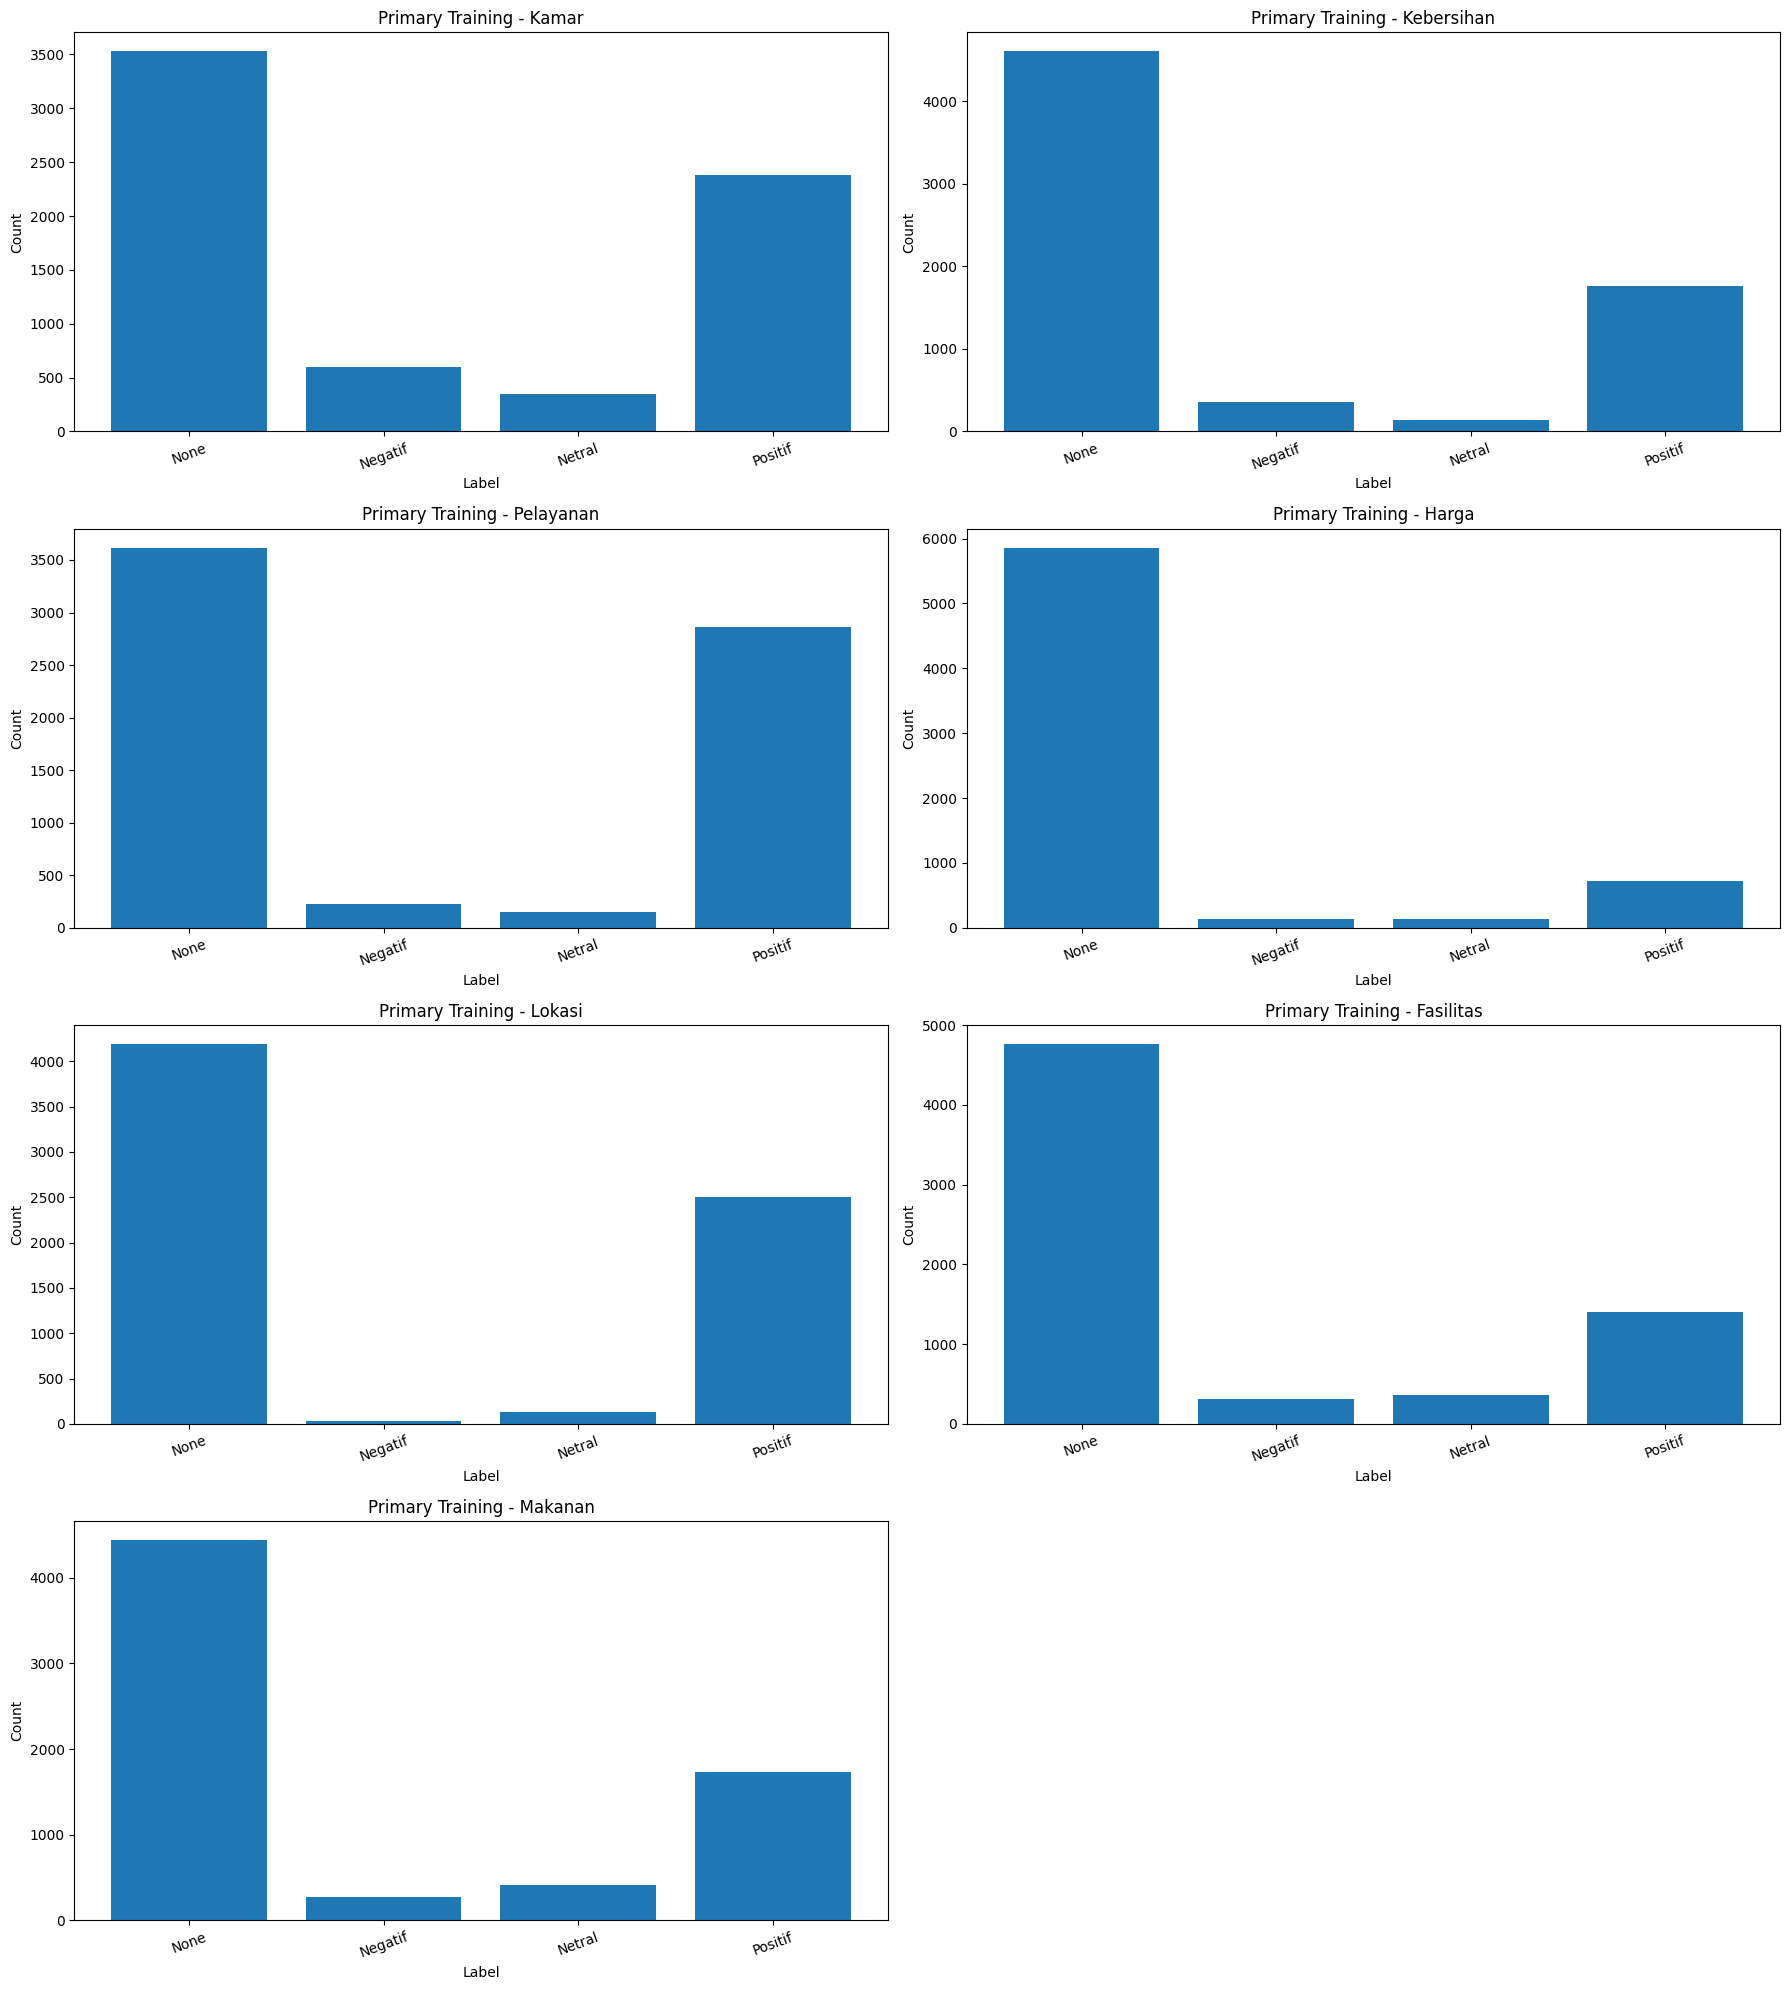

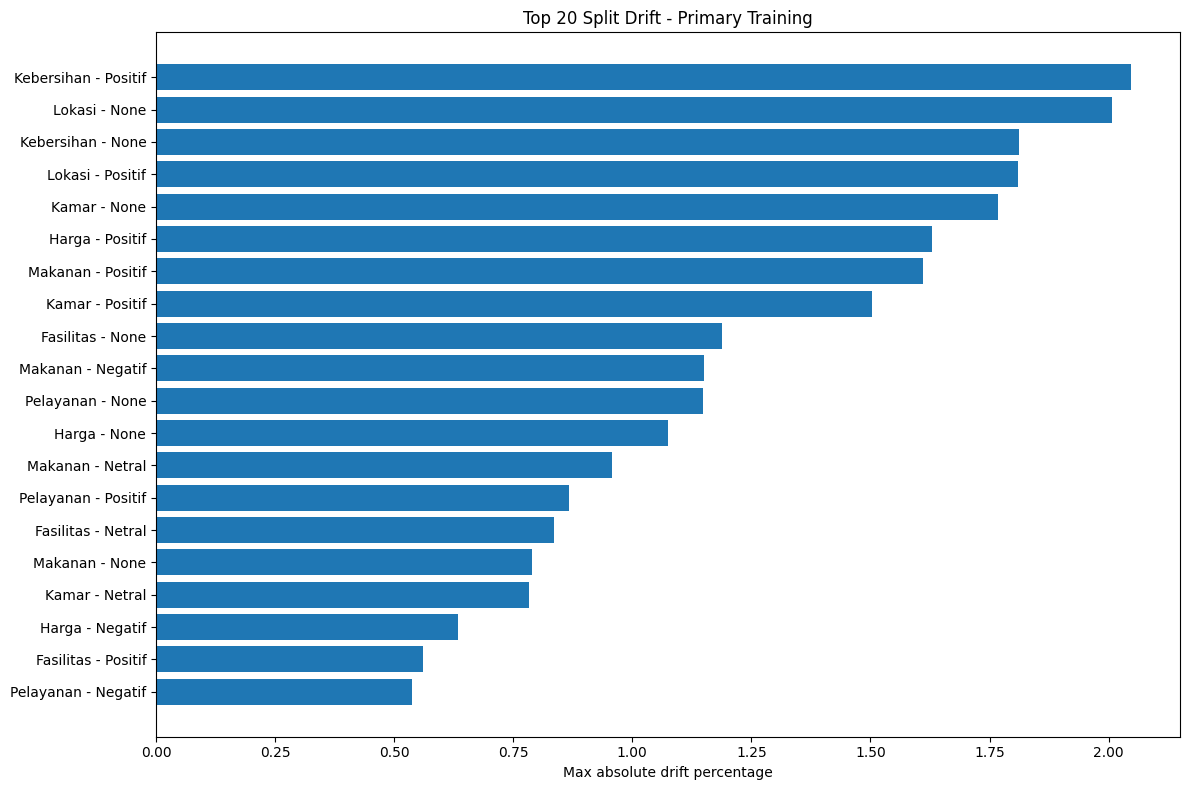

In [9]:
try:
    import matplotlib.pyplot as plt

    primary_global = global_distribution.loc[global_distribution["dataset_variant"].eq("primary_training")]

    fig, axes = plt.subplots(4, 2, figsize=(18, 20))
    axes = axes.flatten()

    for idx, aspect in enumerate(ASPECTS):
        ax = axes[idx]
        plot_df = primary_global.loc[primary_global["aspect"].eq(aspect)]
        ax.bar(plot_df["label"], plot_df["global_count"])
        ax.set_title(f"Primary Training - {aspect}")
        ax.set_xlabel("Label")
        ax.set_ylabel("Count")
        ax.tick_params(axis="x", rotation=20)

    axes[-1].axis("off")
    plt.tight_layout()
    plt.show()

    drift_plot = (
        max_drift.loc[max_drift["dataset_variant"].eq("primary_training")]
        .sort_values("max_abs_drift_percentage", ascending=False)
        .head(20)
        .copy()
    )
    drift_plot["aspect_label"] = drift_plot["aspect"] + " - " + drift_plot["label"]

    plt.figure(figsize=(12, 8))
    plt.barh(drift_plot["aspect_label"], drift_plot["max_abs_drift_percentage"])
    plt.gca().invert_yaxis()
    plt.title("Top 20 Split Drift - Primary Training")
    plt.xlabel("Max absolute drift percentage")
    plt.tight_layout()
    plt.show()

except Exception as exc:
    print("Visualisasi dilewati:", exc)

## Rekomendasi Evaluasi

Karena dataset MABSA memiliki banyak aspek dan label `None` sering dominan, akurasi saja tidak cukup.

Notebook 05 dan seterusnya sebaiknya melaporkan:

- `macro-F1` per aspek.
- `weighted-F1` per aspek.
- `macro-F1` non-None untuk melihat kualitas aspek yang benar-benar muncul.
- confusion matrix per aspek.
- hasil rata-rata semua aspek.
- hasil terpisah untuk `core_clean`, `relation_aware`, dan `contradiction_ablation`.

### 10. Penyusunan Rekomendasi Mitigasi Berdasarkan Hasil Audit


In [10]:
recommendation_rows = []

for dataset_name, df in datasets.items():
    for aspect in ASPECTS:
        audit_subset = split_label_audit.loc[
            (split_label_audit["dataset_variant"].eq(dataset_name))
            & (split_label_audit["aspect"].eq(aspect))
        ]
        status_set = set(audit_subset["audit_status"])
        imbalance_row = imbalance_summary.loc[
            (imbalance_summary["dataset_variant"].eq(dataset_name))
            & (imbalance_summary["aspect"].eq(aspect))
        ].iloc[0]

        notes = []
        if "critical_missing_or_too_few" in status_set:
            notes.append("ada label yang terlalu sedikit pada salah satu split")
        if "rare_label_global" in status_set:
            notes.append("ada label minoritas sangat langka secara global")
        if "high_split_drift" in status_set:
            notes.append("proporsi label antar split agak bergeser")
        if float(imbalance_row["majority_percentage"]) >= 70:
            notes.append("kelas mayoritas dominan")
        if not notes:
            notes.append("distribusi relatif aman")

        recommendation_rows.append({
            "dataset_variant": dataset_name,
            "aspect": aspect,
            "majority_label": imbalance_row["majority_label"],
            "majority_percentage": imbalance_row["majority_percentage"],
            "non_none_percentage": imbalance_row["non_none_percentage"],
            "recommended_primary_metric": "macro_f1",
            "recommended_secondary_metric": "weighted_f1",
            "needs_class_weight": bool(float(imbalance_row["majority_percentage"]) >= 70 or "rare_label_global" in status_set),
            "needs_per_label_report": True,
            "notes": "; ".join(notes),
        })

metric_recommendations = pd.DataFrame(recommendation_rows)
display(metric_recommendations)

,dataset_variant,aspect,majority_label,majority_percentage,non_none_percentage,recommended_primary_metric,recommended_secondary_metric,needs_class_weight,needs_per_label_report,notes
0,all_valid,Kamar,None,48.4682,51.5318,macro_f1,weighted_f1,False,True,distribusi relatif aman
1,all_valid,Kebersihan,None,62.4907,37.5093,macro_f1,weighted_f1,False,True,distribusi relatif aman
2,all_valid,Pelayanan,None,52.2790,47.7210,macro_f1,weighted_f1,False,True,distribusi relatif aman
3,all_valid,Harga,None,85.2553,14.7447,macro_f1,weighted_f1,True,True,kelas mayoritas dominan
4,all_valid,Lokasi,None,61.5691,38.4309,macro_f1,weighted_f1,False,True,distribusi relatif aman
5,all_valid,Fasilitas,None,65.2677,34.7323,macro_f1,weighted_f1,False,True,distribusi relatif aman
6,all_valid,Makanan,None,63.0635,36.9365,macro_f1,weighted_f1,False,True,distribusi relatif aman
7,primary_training,Kamar,None,51.4882,48.5118,macro_f1,weighted_f1,False,True,distribusi relatif aman
8,primary_training,Kebersihan,None,67.2162,32.7838,macro_f1,weighted_f1,False,True,distribusi relatif aman
9,primary_training,Pelayanan,None,52.7867,47.2133,macro_f1,weighted_f1,False,True,distribusi relatif aman


### 11. Audit Kelengkapan File Gambar (Image Manifest Checks)


In [11]:
image_checks = []
if "image_path_found" in image_manifest.columns:
    total_images = len(image_manifest)
    found_images = int(image_manifest["image_path_found"].sum())
    missing_images = total_images - found_images
    image_checks.append({
        "check": "image_path_found_ratio",
        "value": round(found_images / total_images * 100, 4) if total_images else 0.0,
        "expected_min": 99.0,
        "status": "OK" if total_images and found_images / total_images >= 0.99 else "NEEDS_REVIEW",
    })
    image_checks.append({
        "check": "missing_image_rows",
        "value": missing_images,
        "expected_min": 0,
        "status": "OK" if missing_images == 0 else "NEEDS_REVIEW",
    })
else:
    image_checks.append({
        "check": "image_path_found_column",
        "value": "missing",
        "expected_min": "present",
        "status": "NEEDS_REVIEW",
    })

image_path_audit = pd.DataFrame(image_checks)
display(image_path_audit)

,check,value,expected_min,status
0,image_path_found_ratio,100.0,99.0,OK
1,missing_image_rows,0.0,0.0,OK


### 12. Konversi DataFrame ke Format Markdown untuk Laporan


In [12]:
def dataframe_to_markdown(df):
    table = df.copy().fillna("")
    headers = [str(col) for col in table.columns]
    rows = [[str(value) for value in row] for row in table.to_numpy()]
    lines = [
        "| " + " | ".join(headers) + " |",
        "| " + " | ".join(["---"] * len(headers)) + " |",
    ]
    for row in rows:
        lines.append("| " + " | ".join(row) + " |")
    return "\n".join(lines)


summary = {
    "total_dataset_variants": len(datasets),
    "dataset_shapes": {name: {"rows": int(df.shape[0]), "columns": int(df.shape[1])} for name, df in datasets.items()},
    "rare_min_count": RARE_MIN_COUNT,
    "critical_min_count": CRITICAL_MIN_COUNT,
    "max_split_drift_percent": MAX_SPLIT_DRIFT_PERCENT,
    "audit_status_counts": split_label_audit["audit_status"].value_counts().to_dict(),
    "image_path_audit": image_path_audit.to_dict(orient="records"),
    "recommended_main_metric": "macro_f1",
    "recommended_secondary_metric": "weighted_f1",
    "recommended_reporting": [
        "per_aspect_macro_f1",
        "per_aspect_weighted_f1",
        "per_aspect_confusion_matrix",
        "non_none_macro_f1",
        "separate_core_clean_relation_aware_contradiction_ablation",
    ],
}

with open(OUTPUT_DIR / "label_distribution_split_audit_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

methodology_notes = f"""# Methodology Notes - Notebook 04 Label Distribution & Split Audit

## Tujuan

Notebook 04 mengecek apakah pembagian train/validation/test dari Notebook 03 cukup stabil untuk eksperimen MABSA hotel.

## Dasar Metodologi

- Stratifikasi multi-label penting karena satu review memiliki banyak target aspek sekaligus.
- Class imbalance perlu diaudit karena label `None` cenderung dominan, sedangkan label `Negatif` dan `Netral` bisa langka pada aspek tertentu.
- Evaluasi utama sebaiknya memakai macro-F1 dan per-aspect report, bukan accuracy saja.

## Audit Status Counts

{dataframe_to_markdown(split_label_audit["audit_status"].value_counts().rename_axis("audit_status").reset_index(name="count"))}

## Dataset Shapes

{dataframe_to_markdown(pd.DataFrame([{"dataset_variant": name, "rows": df.shape[0], "columns": df.shape[1]} for name, df in datasets.items()]))}

## Image Path Audit

{dataframe_to_markdown(image_path_audit)}

## Keputusan Untuk Notebook 05

1. Gunakan split final dari Notebook 03.
2. Baseline pertama: text-only IndoBERT pada `primary_training`.
3. Laporkan macro-F1, weighted-F1, dan per-aspect F1.
4. Gunakan class weight atau weighted loss untuk aspek dengan mayoritas label terlalu dominan.
5. Jangan mencampur `contradiction_ablation` ke baseline clean; gunakan sebagai evaluasi tambahan.
"""

with open(OUTPUT_DIR / "methodology_notes_notebook_04.md", "w", encoding="utf-8") as f:
    f.write(methodology_notes)

print(json.dumps(summary, ensure_ascii=False, indent=2))

{
  "total_dataset_variants": 5,
  "dataset_shapes": {
    "all_valid": {
      "rows": 8030,
      "columns": 66
    },
    "primary_training": {
      "rows": 6854,
      "columns": 66
    },
    "core_clean": {
      "rows": 4628,
      "columns": 66
    },
    "relation_aware": {
      "rows": 6837,
      "columns": 66
    },
    "contradiction_ablation": {
      "rows": 1176,
      "columns": 66
    }
  },
  "rare_min_count": 10,
  "critical_min_count": 5,
  "max_split_drift_percent": 7.5,
  "audit_status_counts": {
    "ok": 134,
    "critical_missing_or_too_few": 6
  },
  "image_path_audit": [
    {
      "check": "image_path_found_ratio",
      "value": 100.0,
      "expected_min": 99.0,
      "status": "OK"
    },
    {
      "check": "missing_image_rows",
      "value": 0.0,
      "expected_min": 0.0,
      "status": "OK"
    }
  ],
  "recommended_main_metric": "macro_f1",
  "recommended_secondary_metric": "weighted_f1",
  "recommended_reporting": [
    "per_aspect_macro_f1",

### 13. Penyimpanan Dataframe Audit ke Format CSV


In [13]:
def save_csv(df, filename):
    path = OUTPUT_DIR / filename
    df.to_csv(path, index=False, encoding="utf-8-sig")
    return path


saved = []
saved.append(save_csv(label_distribution, "label_distribution_by_dataset_split_aspect.csv"))
saved.append(save_csv(global_distribution, "global_label_distribution_by_dataset_aspect.csv"))
saved.append(save_csv(split_stability, "split_label_stability_detail.csv"))
saved.append(save_csv(max_drift, "split_label_max_drift.csv"))
saved.append(save_csv(imbalance_summary, "imbalance_summary_by_dataset_aspect.csv"))
saved.append(save_csv(split_label_audit, "split_label_audit_flags.csv"))
saved.append(save_csv(metric_recommendations, "metric_recommendations_by_dataset_aspect.csv"))
saved.append(save_csv(image_path_audit, "image_path_audit_notebook_04.csv"))
saved.append(save_csv(invalid_audit, "invalid_distribution_audit_rows.csv"))

print("Saved files:")
for path in saved:
    print("-", path.name)

Saved files:
- label_distribution_by_dataset_split_aspect.csv
- global_label_distribution_by_dataset_aspect.csv
- split_label_stability_detail.csv
- split_label_max_drift.csv
- imbalance_summary_by_dataset_aspect.csv
- split_label_audit_flags.csv
- metric_recommendations_by_dataset_aspect.csv
- image_path_audit_notebook_04.csv
- invalid_distribution_audit_rows.csv


### 14. Pembuatan Rangkuman Verifikasi Kritis (Critical Checks)


In [14]:
checks = []

checks.append({
    "check": "invalid_distribution_audit_rows",
    "value": int(len(invalid_audit)),
    "expected": 0,
})

checks.append({
    "check": "all_dataset_variants_loaded",
    "value": int(len(datasets)),
    "expected": int(len(DATASET_VARIANTS)),
})

for name, df in datasets.items():
    checks.append({
        "check": f"{name}_has_train_val_test",
        "value": int(set(SPLIT_ORDER).issubset(set(df["split"].unique()))),
        "expected": 1,
    })

if "image_path_found" in image_manifest.columns:
    checks.append({
        "check": "image_paths_found_for_all_valid_images",
        "value": int(image_manifest["image_path_found"].sum()),
        "expected": int(len(image_manifest)),
    })

checks.append({
    "check": "metric_recommendations_complete",
    "value": int(len(metric_recommendations)),
    "expected": int(len(datasets) * len(ASPECTS)),
})

checks_df = pd.DataFrame(checks)
checks_df["status"] = np.where(checks_df["value"] == checks_df["expected"], "OK", "NEEDS_REVIEW")
checks_df.to_csv(OUTPUT_DIR / "notebook_04_checks.csv", index=False, encoding="utf-8-sig")
display(checks_df)

if (checks_df["status"] == "NEEDS_REVIEW").any():
    print("Notebook 04 selesai dengan catatan. Cek baris NEEDS_REVIEW sebelum Notebook 05.")
else:
    print("Notebook 04 selesai. Distribusi label dan split siap untuk Notebook 05 text-only IndoBERT baseline.")

,check,value,expected,status
0,invalid_distribution_audit_rows,0,0,OK
1,all_dataset_variants_loaded,5,5,OK
2,all_valid_has_train_val_test,1,1,OK
3,primary_training_has_train_val_test,1,1,OK
4,core_clean_has_train_val_test,1,1,OK
5,relation_aware_has_train_val_test,1,1,OK
6,contradiction_ablation_has_train_val_test,1,1,OK
7,image_paths_found_for_all_valid_images,17371,17371,OK
8,metric_recommendations_complete,35,35,OK


Notebook 04 selesai. Distribusi label dan split siap untuk Notebook 05 text-only IndoBERT baseline.


### 15. Ruang Eksekusi Tambahan (Opsional)


### 16. Pembuatan Arsip ZIP untuk Seluruh Hasil Audit


In [15]:
zip_base = OUTPUT_DIR.parent / "mabsa_label_distribution_split_audit_outputs"
zip_path = shutil.make_archive(str(zip_base), "zip", root_dir=OUTPUT_DIR)
print("ZIP output:", zip_path)
print("\nFiles in output directory:")
for path in sorted(OUTPUT_DIR.glob("*")):
    print("-", path.name)

ZIP output: /kaggle/working/mabsa_label_distribution_split_audit_outputs.zip

Files in output directory:
- global_label_distribution_by_dataset_aspect.csv
- image_path_audit_notebook_04.csv
- imbalance_summary_by_dataset_aspect.csv
- invalid_distribution_audit_rows.csv
- label_distribution_by_dataset_split_aspect.csv
- label_distribution_split_audit_summary.json
- methodology_notes_notebook_04.md
- metric_recommendations_by_dataset_aspect.csv
- notebook_04_checks.csv
- split_label_audit_flags.csv
- split_label_max_drift.csv
- split_label_stability_detail.csv
